2.	Perform a non-linear regression algorithm to predict China’s GDP from year 1960 to 2014 from given features. Elaborate gradient descent algorithm and hyper-parameter tuning for the best result with predefined convergent criteria.

Dataset: china_gdp.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("china_gdp.csv")
df.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


In [ ]:
X = df["Year"].values
y = df["Value"].values

In [ ]:
X_scaled = (X - X.mean()) / X.std()
y_scaled = (y - y.mean()) / y.std()

In [ ]:
def sigmoid(x, theta1, theta2):
    return 1 / (1 + np.exp(-theta1 * (x - theta2)))

In [ ]:
theta1 = 1.0
theta2 = 0.0
alpha = 0.01
iterations = 10000
m = len(X_scaled)
tolerance = 1e-6
costs = []

In [ ]:
for i in range(iterations):
    y_pred = sigmoid(X_scaled, theta1, theta2)
    error = y_pred - y_scaled
    cost = (1 / (2 * m)) * np.sum(error**2)
    costs.append(cost)
    d_theta1 = (1 / m) * np.sum(error * y_pred * (1 - y_pred) * (X_scaled - theta2))
    d_theta2 = (1 / m) * np.sum(error * y_pred * (1 - y_pred) * (-theta1))
    theta1 -= alpha * d_theta1
    theta2 -= alpha * d_theta2
    if i > 1 and abs(costs[-2] - cost) < tolerance:
        print(f"Converged at iteration {i}")
        break
print(f"Optimized Parameters: theta1 = {theta1:.4f}, theta2 = {theta2:.4f}")

Converged at iteration 2
Optimized Parameters: theta1 = 5.1033, theta2 = 1.0504


In [ ]:
y_pred_scaled = sigmoid(X_scaled, theta1, theta2)

In [ ]:
y_pred = y_pred_scaled * y.std() + y.mean()

In [ ]:
r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.4555


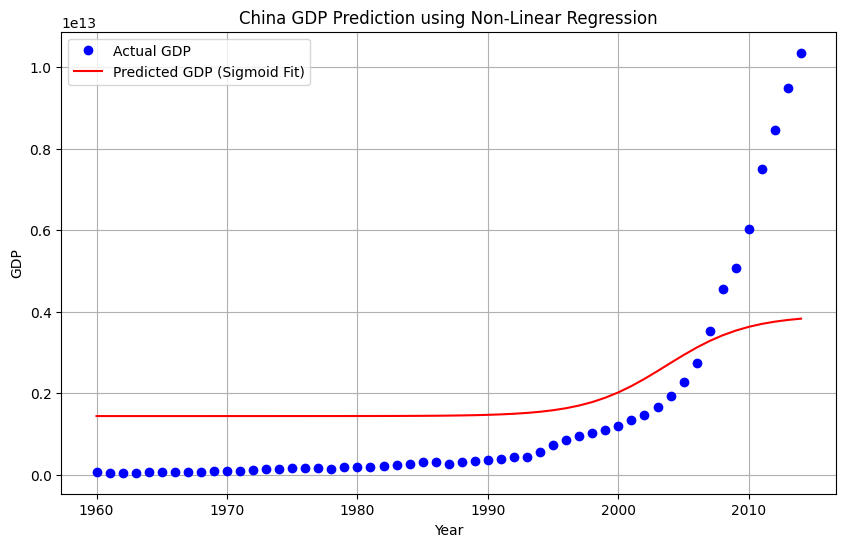

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'bo', label='Actual GDP')
plt.plot(X, y_pred, 'r-', label='Predicted GDP (Sigmoid Fit)')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title("China GDP Prediction using Non-Linear Regression")
plt.legend()
plt.grid(True)
plt.show()